### Patch Antenna
We now apply a refined mesh for the patch antenna. Because the electromagnetic fields change rapidly near the metallic patch and the substrate edges, we increase the mesh density in these areas to ensure high simulation accuracy for resonance and radiation patterns.

In [1]:
import gmsh
import math

from palacetoolkit.plot_farfield import load_data, polar_plots, three_d_plot
from palacetoolkit.postpro import s_params
from palacetoolkit.simulation import generate_palace_config_from_entities
from palacetoolkit.viz import view_mesh
from palacetoolkit.mesh import (
    Entity, 
    run_meshing_pipeline, 
    generate_3d_mesh, 
    refine_near_surfaces
)


### Parameters:
- l : Patch length along x-axis, specified as a scalar in meters.
- w : Patch width along y-axis, specified as a scalar in meters.
- h : Patch height along z-axis, specified as a scalar in meters. 
- l1 : Ground plane length along x-axis, specified as a scalar in meters
- w1 : Ground plane width along y-axis, specified as a scalar in meters
- l2 : Notch length along x-axis, specified as a scalar in meters. 
- w2 : Notch width along x-axis, specified as a scalar in meters. 
- w3 : Strip line width along y-axis, specified as a scalar in meters.
- air_height : Air box height along z-axis, specified as a scalar in meters.  
- air_margin : Air box margin along x and y axes, specified as a scalar in meters.
- freq  : Simulation frequency in GHz, specified as a scalar.
- filename : Output mesh filename, specified as a string.
- eps_r: relative permittivity of the substrate
- loss_tan: loss tangent of the substrate
- port_impedance: characteristic impedance of the lumped port (Ohms)

In [2]:
# Patch
l: float = 0.030
w: float = 0.029

# Ground plane
l1: float = 0.06
w1: float = 0.06

# Notch
l2: float = 0.008
w2: float = 0.003

# Feed line
w3: float = 0.002

# Substrate
h: float = 0.0013

freq: float = 3.3
eps_r: float = 2.2
loss_tan: float = 0.0009
mu_r = 1.0
port_impedance: float = 50.0
wavelength = 3e8 / (freq * 1e9)

# Air box
air_height: float = wavelength
air_margin: float = wavelength / 2

# Filename where the mesh is loadeds
filename = "patch_antenna.msh"

### Initialize the model

In [3]:
gmsh.initialize()
gmsh.model.add("patch_antenna")
kernel = gmsh.model.occ

### Geometry Construction
In this step, we build the physical structure of the patch antenna. We define the substrate, the metallic ground plane, and the antenna patch itself.

Patch Design: We combine the main patch and the feed line, including an inset to help with impedance matching.
Excitation: A lumped port is created and positioned to feed the antenna.
Domain Setup: We enclose the entire structure in an "air box," which defines the simulation region (the radiation space).
Finalizing: We use boolean operations (fragmenting) to ensure all components are properly connected and recognized as a single cohesive model by the solver.

In [4]:
# Total domain bounds
total_xmin = -l1/2 - air_margin
total_xmax = l1/2 + air_margin
total_ymin = -w1/2 - air_margin
total_ymax = w1/2 + air_margin
total_zmin = -air_height/2
total_zmax = h + air_height/2

substrate = kernel.addBox(-l1/2, -w1/2, 0, l1, w1, h)

# Ground plane
ground_plane = kernel.addRectangle(-l1/2, -w1/2, 0, l1, w1)

# Patch definition
main_patch = kernel.addRectangle(-l/2, -w/2, h, l, w)
inset = kernel.addRectangle(-l/2, -w2/2, h, l2, w2)

patch_dimtags, _ = kernel.cut(
    [(2, main_patch)], 
    [(2, inset)], 
    removeObject=True, removeTool=True
)
kernel.synchronize()

feed_length = (l1 - l)/2 + l2
feed_line = kernel.addRectangle(-l1/2, -w3/2, h, feed_length, w3)

# Our patch
top_conductor, _ = kernel.fuse(
    patch_dimtags, [(2, feed_line)],
    removeObject=True, removeTool=True
)
kernel.synchronize()

# Gap bewteen the gropund plane and the bottom of the lumped port.
lumped_port = kernel.addRectangle(-l1/2, -w3/2, 0, h, w3)
kernel.rotate([(2, lumped_port)], -l1/2, 0, 0, 0, 1, 0, -math.pi/2)
kernel.synchronize()

air_box = kernel.addBox(
    total_xmin, total_ymin, total_zmin,
    total_xmax - total_xmin,
    total_ymax - total_ymin,
    total_zmax - total_zmin
)
kernel.synchronize()

Info    : Cannot bind existing OpenCASCADE surface 8 to second tag 9                                                      
Info    : Could not preserve tag of 2D object 9 (->8)


### Entities definition and mesh refinement.

In [5]:
# Define the entities which later will become the physical groups.
entities = [
    Entity("air_box", dim = 3, mesh_order = 2, btype = "dielectric", tags = [air_box], loss_tan = 0.0, eps_r = 1.0, mu_r = 1.0),
    Entity("substrate", dim = 3, mesh_order = 1, btype = "dielectric", tags = [substrate], loss_tan = loss_tan, eps_r = eps_r, mu_r = mu_r),
    Entity("top_conductor", dim = 2, mesh_order= 1, btype = "pec", tags = [top_conductor[0][1]]),
    Entity("ground_plane", dim = 2, mesh_order = 1, btype = "pec", tags = [ground_plane]),
    Entity("lumped_port", dim = 2, mesh_order = 0, btype = "lumped_port", tags = [lumped_port], R = port_impedance, direction = '+Z', excitation = True)
]

# Boolean operations to guarantee a nice mesh, algo it returns the
# physical group map.
pg_map = run_meshing_pipeline(entities)

# Refine near the top conductor and locally the lumped port
refine_near_surfaces(entities[2].dimtags + entities[-1].dimtags, 
                     wavelength, 
                     ppw_near=400, 
                     ppw_far=7, 
                     set_as_background=True)

# Mesh sizes
mesh_sizes = {
    "substrate": wavelength / 12,
    "air_box": wavelength / 4,
    "lumped_port": wavelength / 150,
    "ground_plane" : wavelength / 10,
    "top_conductor": wavelength / 50
}

generate_3d_mesh(entities, mesh_sizes, filename, optimize=True)
gmsh.option.setNumber("Mesh.MshFileVersion", 2.2)
gmsh.write(filename)
gmsh.finalize()

  Physical group 'air_box' (dim=3): pg=1, tags=[2]                                                                                               
  Physical group 'substrate' (dim=3): pg=2, tags=[1]
  Physical group 'top_conductor' (dim=2): pg=3, tags=[8]
  Physical group 'ground_plane' (dim=2): pg=4, tags=[7]
  Physical group 'lumped_port' (dim=2): pg=5, tags=[9]
  Physical group 'air_box__None' (dim=2): pg=6, tags=[16, 17, 18, 19, 20, 21]
  Physical group 'air_box__substrate' (dim=2): pg=7, tags=[10, 11, 13, 15, 14, 12]
  ppw_near=400  ppw_far=7
  SizeMax=0.0130  transition=0.0227
  global: 15 curves, SizeMin=0.0002
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 45 (Line)
Info    : [ 10%] Meshing curve 46 (Line)
Info    : [ 10%] Meshing curve 47 (Line)
Info    : [ 10%] Meshing curve 48 (Line)
Info    : [ 10%] Meshing curve 49 (Line)
Info    : [ 20%] Meshing curve 50 (Line)
Info    : [ 20%] Meshing curve 51 (Line)
Info    : [ 20%] Meshing curve 52 (Line)
Info    : [ 20%] Meshi

### Mesh visualization

In [6]:
view_mesh(filename, transparent_groups= "air_box__None")

Loading mesh file: patch_antenna.msh
Groups to render transparent: air_box__None

Mesh loaded successfully with 2 cell blocks
Found 10192 triangles total
Physical group tags in mesh: {3: 'top_conductor', 4: 'ground_plane', 5: 'lumped_port', 6: 'air_box__None', 7: 'air_box__substrate'}


### Simulation Configuration
We define the key parameters for the electromagnetic simulation here. These settings control the frequency sweep range, material properties (dielectric constant and loss tangent for the substrate), and solver-specific configurations like port impedance and mesh order.

- output_file  : output filename for the configuration JSON file
- freq_min : minimum frequency for the simulation (GHz)  
- freq_max: maximum frequency for the simulation (GHz)
- freq_step: frequency step for the simulation (GHz)
- solver_order: order of the finite element basis functions for the simulation (e.g., 1 for linear, 2 for quadratic)

In [ ]:
output_file: str = "patch_antenna.json"
# Sweep de simulación 
freq_min: float = 2.5
freq_max: float = 4
freq_step: float = 0.0025

solver_order: int = 2

### Generating the Palace Configuration File
Finally, we assemble the simulation parameters into a JSON configuration .

In [8]:
generate_palace_config_from_entities(entity_defs = [e.to_dict() for e in entities],
    pg_map = pg_map,
    mesh_file = filename,
    output_file = 'patch.config',
    freq_min = freq_min,
    freq_max = freq_max,
    freq_step = freq_step ,
    L0 = 1.0,
    solver_order = solver_order,
    absorbing_order = 2,
    farfield=True)

Palace config written to patch.config


{'Problem': {'Type': 'Driven', 'Verbose': 2, 'Output': 'postpro/patch'},
 'Model': {'Mesh': 'patch_antenna.msh', 'L0': 1.0, 'Refinement': {}},
 'Domains': {'Materials': [{'Attributes': [1],
    'Permeability': 1.0,
    'Permittivity': 1.0,
    'LossTan': 0.0},
   {'Attributes': [2],
    'Permeability': 1.0,
    'Permittivity': 2.2,
    'LossTan': 0.0009}]},
 'Boundaries': {'PEC': {'Attributes': [3, 4]},
  'Absorbing': {'Attributes': [6], 'Order': 2},
  'LumpedPort': [{'Index': 1,
    'Attributes': [5],
    'R': 50.0,
    'Excitation': True,
    'Direction': '+Z'}],
  'Postprocessing': {'FarField': {'Attributes': [6], 'NSample': 16000}}},
 'Solver': {'Order': 2,
  'Device': 'CPU',
  'Driven': {'MinFreq': 2,
   'MaxFreq': 5,
   'FreqStep': 0.025,
   'SaveStep': 5,
   'AdaptiveTol': 0.001},
  'Linear': {'Type': 'Default',
   'KSPType': 'GMRES',
   'Tol': 1e-08,
   'MaxIts': 500}}}

### Running Palace

In [9]:
from palacetoolkit.simulation import set_palace_path, run_palace
run_palace(config_file="patch.config", num_procs=16)

  Running: /home/martin/.cache/palacetoolkit/runtime/palace-cpu-v0.1.2/bin/palace -np 16 /home/martin/Desktop/PalaceToolkit/docs/examples/patch.config
>> /usr/bin/mpirun -n 16 /home/martin/.cache/palacetoolkit/runtime/palace-cpu-v0.1.2/bin/palace-x86_64.bin /home/martin/Desktop/PalaceToolkit/docs/examples/patch.config

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (postpro/patch)
Git changeset ID: v0.16.1-51-g4f2e2d97
Running with 16 MPI processes, 1 OpenMP thread
Device configuration: omp,cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Added 2167 duplicate vertices for interior boundaries in the mesh
Added 5149 duplicate boundary elements for interior boundaries in the mesh

Characteristic length and time scales:
 Lc = 1.509e-01 m,

### Post processing.

We want to see the S parameters, H plane, E plane and the radiation pattern.

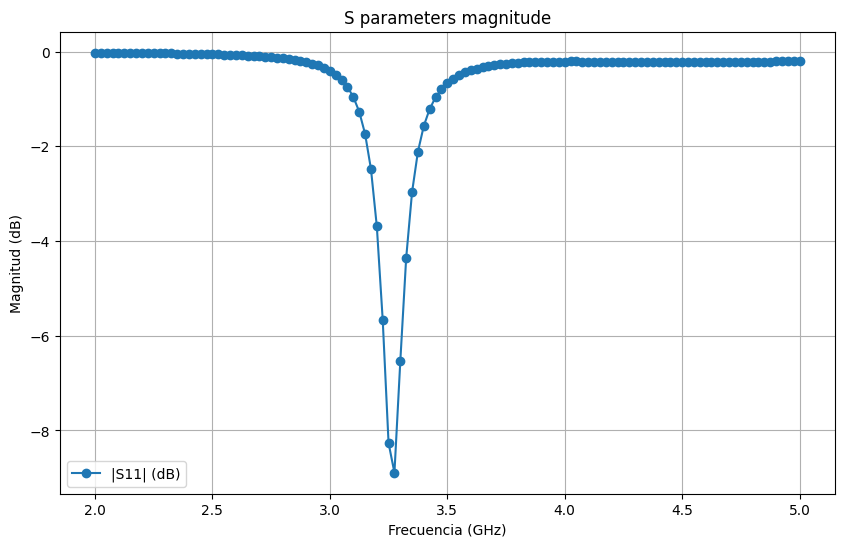

In [10]:
# S parameters. Return the frequency where the minimum is reached.
from pathlib import Path

notebook_dir = Path().resolve()
postpro_dir = notebook_dir / "postpro" / "patch"

f = s_params(str(postpro_dir / "port-S.csv"))

Columns found: ['f', 'theta', 'phi', 'r*Re{E_x}', 'r*Im{E_x}', 'r*Re{E_y}', 'r*Im{E_y}', 'r*Re{E_z}', 'r*Im{E_z}']
Processing frequency: 3.275 GHz  (16000 rows)
Extracting E-plane...
  E-plane phi~0°:   298 points
  E-plane phi~180°: 458 points
Extracting H-plane...
  H-plane theta~90°: 1922 points


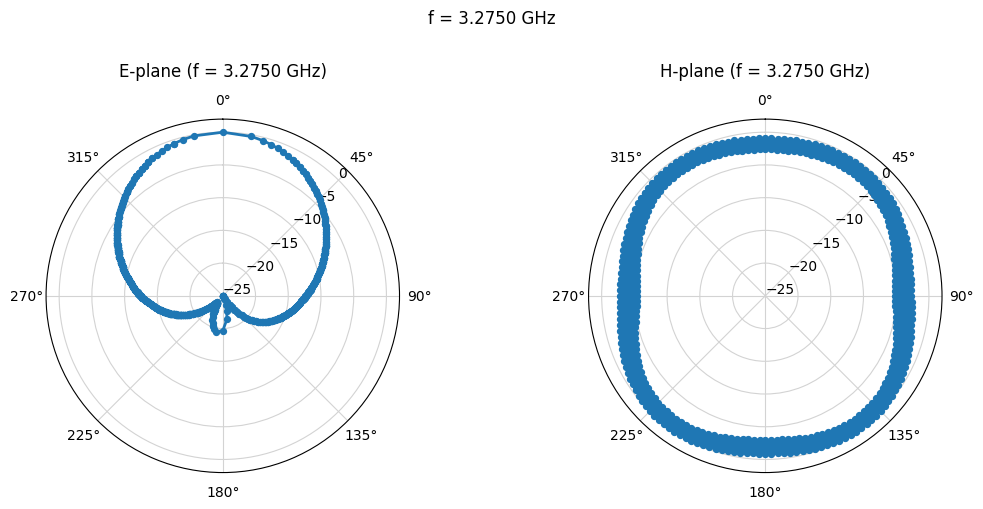

In [11]:
data, label = load_data(str(postpro_dir / "farfield-rE.csv"), f)
polar_plots(data, label)

In [12]:
# Radiation pattern.
three_d_plot(
        data, 
        label,
        n_theta           = 360,
        n_phi             = 720,
        n_smooth          = 100,
        taubin_pass_band  = 0.1,
    )

/home/martin/Desktop/PalaceToolkit/src/palacetoolkit/plot_farfield.py:207: PyVistaFutureWarning: The default value of `algorithm` for the filter
`StructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  mesh = grid.extract_surface()


Widget(value='<iframe src="http://localhost:46503/index.html?ui=P_0x760670cb35f0_0&reconnect=auto" class="pyvi…